Before you submit this assignment, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel$\rightarrow$Restart) and then **run all cells** (in the menubar, select Cell $\rightarrow$ Run All).

Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE".

# ES98E Assignment 5 - Neural Networks

## Workshop Aims

- Explore non-linear regression with Neural Networks
- Understand the origin of the bias-variance tradeoff when fitting models to limited data
- Compare regression for the water molecule dataset using neural networks and Gaussian processes

**Note**: *The maximum available points for this assignment is 120: 100 points for the core material that everyone is expected to attempt, and 20 points for extension material which is optional, but assessed. The highest percentage you could get on this assignment without attempting the extension material is 100/120 = 83.3%*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

import jax.random
import tinygp
from gputils import gp_print, gp_plot, gp_fit_restarts

import torch, torch.nn as nn
import torchsummary
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import StepLR

# Customize default plotting style
%matplotlib inline
import seaborn as sns
sns.set_context('talk')

In [2]:
plt.rcParams["figure.figsize"] = (10, 8)

# Part 1: Bias-Variance Trade-Off

This section investigates the bias-variance trade-off for a toy model used throughout chapter 8 of Simon Prince's book *Understanding Deep Learning* and reproduces the bias/variance trade off figure shown in the lecture.

**Note**: We use a different toy function here than the Gabor model used in Lecture 5. This simpler function makes it easier to visualise the bias-variance decomposition, while the Gabor model was chosen in the lecture to demonstrate more realistic fitting challenges.

We provide a simple function to use as a source of data. It is defined as
$$
y = e^{\sin(2\pi x)}
$$
on the interval $x \in [0, 1]$.

In [3]:
# The true function that we are trying to estimate, defined on [0,1]
def true_function(x):
    y = np.exp(np.sin(x * (2 * np.pi)))
    return y

You are also provided with a function to generate data points from noisy observations of the true function, taking care that it can also be used to produce data without noise, and that the input values are spaced somewhat uniformly along the $x$-axis, and  function to plot data. See the code and documentation strings for details.

In [4]:
def generate_data(n_data, sigma_y=0.3):
    """
    Generate some data points with or without noise
    
    Arguments:
    
    n_data: int 
        Number of input points
    sigma_y: float
        Standard deviation of Gaussian noise to add to observations
        
    Returns:

    X: array shape (n_data, 1)
        Matrix with input values in first column
    y: array shape (n_data, )
        Vector of noisy function values at inputs `X[:, 0]`
    """
    # Generate x values quasi uniformly
    x = np.zeros(n_data)
    for i in range(n_data):
        x[i] = np.random.uniform(i/n_data, (i+1)/n_data)
    
    # y value from running through function and adding noise
    y = true_function(x) + np.random.normal(0, sigma_y, n_data)
    
    # add an empty second dimension for compatibility with regression codes
    X = x[:, None]
    return X, y

def plot_function(x_func, y_func, 
                  X_data=None, y_data=None, 
                  x_model=None, y_model=None, 
                  function_sigma=None, model_sigma=None, 
                  ax : plt.Axes=None, data_fmt='o'):
    """
    Plot some combination of true function, data and model predictions with uncertainties

    Arguments which are not passed are not included in the plot.
    
    Arguments:

    x_func: array shape(n_grid)
        Input coordinates at which true function has been evaluated
    y_func: array shape(n_grid)
        Values of true function at inputs x_func, without noise
    X_data: array shape(n_data, 1)
        Matrix of input data. Note second singleton dimension!
    y_data: array shape(n_data, )
        Vector of noisy function observations at inputs `X_data[:, 0]`.
    function_sigma: float or array
        Uncertainty in function observations. Typically a scalar for homoscedastic 
        uncertainties in the data generating procedure.
    model_sigma: array
        Uncertainties in model predictions. Typically a vector of heteroscedastic 
        uncertainties in regression outputs.
    ax: plt.Axes
        If passed, draw on this Axes object
    data_fmt: string
        Plot symbol to use for data points, passed to `plt.plot()`. 
        Default 'o', use '.' for smaller points.
    """
    
    # 
    if ax is None:
        fig, ax = plt.subplots()
    ax.plot(x_func, y_func, 'k-', label='True function')
    if function_sigma is not None:
        ax.fill_between(x_func, y_func - 2*function_sigma, y_func + 2*function_sigma, color='k', alpha=0.1,
                        label='Function uncertainty')

    if X_data is not None:
        ax.plot(X_data, y_data, data_fmt, color='C1', label='Data')

    if x_model is not None:
        ax.plot(x_model, y_model, '-', color='C0', label='Model')

    if model_sigma is not None:
        ax.fill_between(x_model, y_model - 2*model_sigma, y_model + 2*model_sigma, 
                        color='C0', alpha=0.3, label='Model uncertainty')

    ax.set_xlim(0,1)
    ax.set_xlabel('Input, $x$')
    ax.set_ylabel('Output, $y$')

### Question 1.a

Adapt the code below to produce a plot of the true function and 15 data points with noise $\mathcal{N}(0, \sigma^2)$ with $\sigma = 0.3$. Use the `sigma_function` argument to `plot_function` to show the uncertainty in the function values.

<div align="right">[5 points]</div>

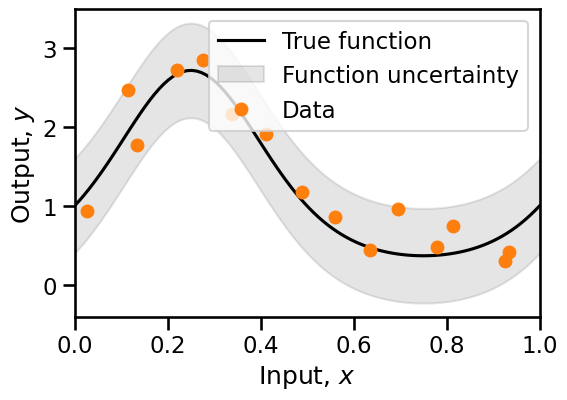

In [5]:
# Generate true function
x_func = np.linspace(0, 1.0, 100)
y_func = true_function(x_func)

# Generate some data points
np.random.seed(1)
function_sigma = 0.3
n_data = 15

# YOUR CODE HERE
X_data, y_data = generate_data(n_data, sigma_y=function_sigma)
fig, ax = plt.subplots(figsize=(6, 4))
plot_function(
    x_func=x_func,
    y_func=y_func,
    X_data=X_data,
    y_data=y_data,
    function_sigma=function_sigma,
    ax=ax,
    data_fmt='o'
)
ax.legend()
plt.show()

### Linear Hidden Unit Neural Network

Here we will use a 'toy' neural network model with linear activation functions and $N_h=3$ hidden units as illustrated below. This is adapted from the model presented in Chapter 8 of Simon Prince's book, [Understanding Deep Learning](https://udlbook.github.io/udlbook/), where this figure is also reproduced from.

In this model, the weights and biases between the input and hidden layers, shown with dashed lines in panel (a), are fixed to ensure the hidden unit activations shown in panels (b)-(d) have slopes of one, and their joints are equally space across the interval $[0, 1]$ at $x=0$, $x=1/3$ and $x=2/3$. The remaining 4 free parameters are $\mathbf{w} = (\beta, w_1, w_2, w_3)$. 

Modifying these 4 parameters allows any piecewise linear function over $x \in [0,1]$ with joints at 1/3 and 2/3 to be created, such as the three examples shown in panels (e)-(g).

<img src="toymodel.png">

As well as being easy to understand, this model maps onto a least squares problem which means that the parameters can be determined in closed form without the need for stochastic optimisation.

Here is an implementation of the forward pass through the network. You don't need to modify it, but you should read the code to understand how it works.

In [9]:
def relu(x):
    return np.clip(x, a_min=0, a_max=None)

def network(x, beta, omega):
    # Retrieve number of hidden units
    n_hidden = omega.shape[0]

    y = np.zeros_like(x)
    for c_hidden in range(n_hidden):
        # Evaluate activations based on shifted lines
        h = relu(x - c_hidden/n_hidden)
        
        # Weight activations by omega parameters and sum
        y = y + omega[c_hidden] * h
    # Add bias, beta
    y = y + beta
    return y

### Fitting the Model in Closed Form

The code provided below fits the $N_h$+1 parameters - 3 weights and 1 bias for the case of $N_h=3$ shown in the figure above - in closed form. It is a least squares solution of the problem $A\mathbf{w} = \mathbf{y}$ in the form 

$$
\mathbf{w} = (A{^T}A)^{-1}A^T\mathbf{y}
$$

where $A$ is a design matrix with elements $A_{ij} = \phi_j(x_i)$, $0 \le i < N_d$ for the $N_d$ rows of observations and $0 \le j \le N_h$ for the $N_h+1$ basis functions (using zero-based indices to ease comparison with the Python code below).

Again, you don't need to dig into all the details of how this works, but if you are curious the basis functions are given by

$$
\begin{align}
\phi_0(x) &= 1 \\
\phi_j(x) &= \mathrm{ReLU}(W\mathbf{x}) = \mathrm{ReLU}\Big[ \begin{pmatrix}(1,  &-\frac{j-1}{D_h})\end{pmatrix}^T \begin{pmatrix}x \\ 1\end{pmatrix} \Big], 1 \le j \le N_h
\end{align}
$$
<!--
$$
\begin{align}
\phi_0(x) &= 1 \\
\phi_j(x) &= \mathrm{ReLU}\Big(x - \frac{j-1}{D_h}\Big), 1 \le j \le N_h
\end{align}
$$
-->

where the weight matrix $W$ has been defined to reproduce the shifted 'elbow' functions illustrated above. This approach fits into the code framework introduced earlier in the module (or in PX914 if you are doing the 10 credit variant of ES98E).

In [10]:
class LinearNNBasis:
    def __init__(self, n_hidden):
        self.n_hidden = n_hidden
        self.num_basis = n_hidden + 1
        self.weights1 = np.ones(n_hidden)
        self.biases1 = -np.arange(n_hidden) / n_hidden
        
    def __call__(self, x):
        res = np.zeros(self.num_basis)
        res[0] = 1.0
        for j in range(1, self.num_basis):
            res[j] = relu(x[0] * self.weights1[j-1] + self.biases1[j-1])
        return res
    
from blr import design_matrix

def fit_model_closed_form(X, y, n_hidden=3):
    n_data = X.shape[0]
    phi = LinearNNBasis(n_hidden)
    A = design_matrix(X, phi)
    beta_omega = np.linalg.lstsq(A, y, rcond=None)[0]
    beta = beta_omega[0]
    omega = beta_omega[1:]
    return beta, omega

### Question 1.b

Use the `fit_model_closed_form()` function provided above to fit the model to the input values  `X_data` and outputs `y_data`. Predict the outputs of the network for the full range of $x \in [0,1]$ and plot the true function, data and fitted model using the `plot_function()` routine provided.

<div align="right">[5 points]</div>

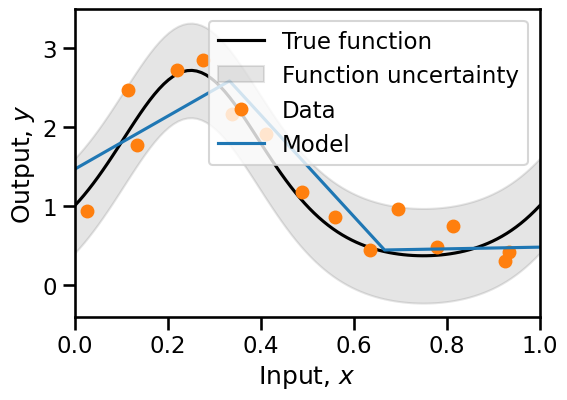

In [11]:
# YOUR CODE HERE
beta_pred, omega_pred = fit_model_closed_form(X_data, y_data)

model_y = network(x_func, beta_pred, omega_pred)

fig, ax = plt.subplots(figsize=(6, 4))
plot_function(
    x_func=x_func,
    y_func=y_func,
    X_data=X_data,
    y_data=y_data,
    x_model=x_func,
    y_model=model_y,
    function_sigma=0.3,
    ax=ax,
    data_fmt='o'
)
ax.legend()
plt.show()

### Question 1.c

**Complete the implementation of `get_model_mean_variance()`.**

We will now calculate the mean and variance of the model as the training set is varied.  To do this we will train across several different sets of random samples from `generate_data()`.

- Ensure you pass along the `n_hidden` parameter to the solver; otherwise the default value of `n_hidden=3` will be used which will cause problems later when we want to vary the model capacity.
- This function should repeat the steps you carried out above to run the model many times with different datasets and return the mean and variance of the predictions. 
- Each of the `n_dataset` datasets should contain `n_data` observations with noise `function_sigma`. You should use `generate_data()` to do this.
- The model can be fit in closed form as above.
- The fitted model should be used to make predictions on the 100-point interval `x_model` provided.
- The `solver` argument defaults to calling `fit_model_closed_form()` defined above. You only need to change this if you want to complete the extension exercise below on L2 regularisation.

<div align="right">[10 points]</div>

In [12]:
x_model = np.linspace(0, 1, 100)

# Run the model many times with different datasets and return the mean and variance
def get_model_mean_variance(n_data, n_datasets, n_hidden, function_sigma, solver=fit_model_closed_form):

    # Create array that stores model results in rows
    y_model_all = np.zeros((n_datasets, x_model.shape[0]))

    for c_dataset in range(n_datasets):
        # YOUR CODE HERE
        X, y = generate_data(n_data, sigma_y=function_sigma)
        beta_pred, omega_pred = solver(X, y, n_hidden=n_hidden)
        y_model_all[c_dataset, :] = network(x_model, beta_pred, omega_pred)

    # Get mean and standard deviation of model
    mean_model = np.mean(y_model_all, axis=0)
    std_model = np.std(y_model_all, axis=0)

    # Return the mean and standard deviation of the fitted model
    return mean_model, std_model

Use this cell to check your solution above.  It should generate 100 random data sets of the same size, fit the model 100 times and plot the mean and variance in predictions. As well as looking visually reasonable, it should also pass the quantitative tests in the cell below.

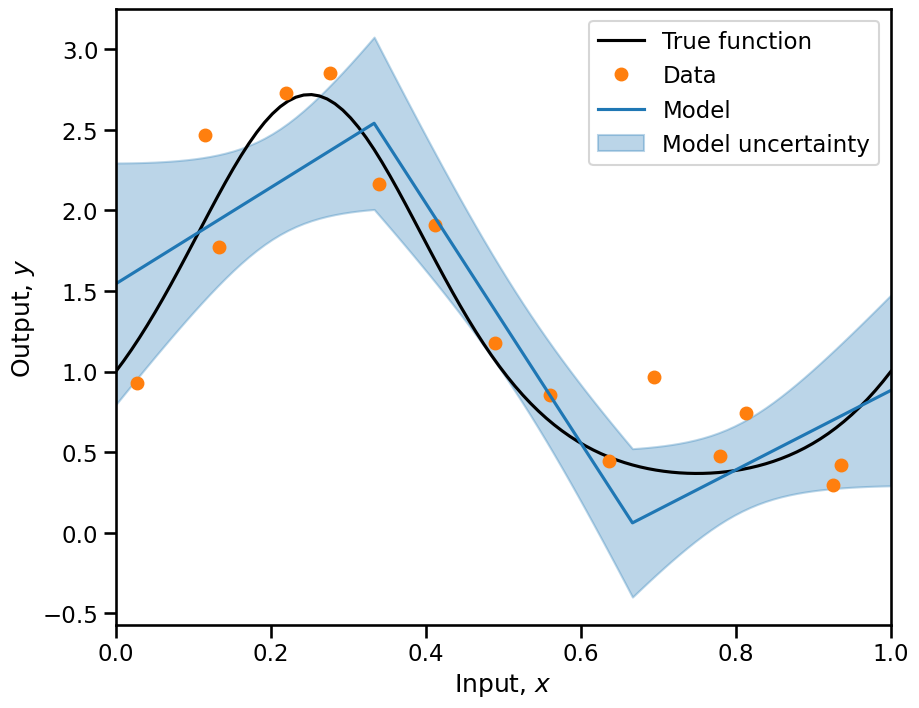

In [13]:
np.random.seed(1)
mean_model, std_model = get_model_mean_variance(n_data=10, n_datasets=100, n_hidden=3, function_sigma=0.3)

# Plot the results
plot_function(x_func, y_func, X_data, y_data, x_model, mean_model, model_sigma=std_model)
plt.legend();

In [14]:
# Get mean and variance of fitted model
np.random.seed(1) # for reproducibility
mean_model, std_model = get_model_mean_variance(n_data=10, n_datasets=10, n_hidden=3, function_sigma=0.3)
assert abs(mean_model[0] - 1.67359729) < 1e-4
assert abs(mean_model[-1] - 0.8723615) < 1e-4
assert abs(std_model[0] - 0.32785361) < 1e-4
assert abs(std_model[-1] - 0.24648939) < 1e-4

# Try with n_hidden=4 to ensure this parameter is correctly passed along
mean_model_4, std_model_4 = get_model_mean_variance(n_data=10, n_datasets=10, n_hidden=4, function_sigma=0.3)
assert abs(mean_model_4[0] - 1.25389723) < 1e-4
assert abs(mean_model_4[-1] - 0.89518150) < 1e-4

### Question 1.d


Experiment with changing the number of data points and the number of hidden variables (the *model capacity*, which we'll explore more carefully in Q1.e below) in the model.  Get a feeling for what happens in terms of the **bias** (squared deviation between dark blue and black lines) and the **variance** (light blue shaded region) as we manipulate these quantities.

Illustrate your findings with a plot containing at most 6 subpanels in the code cell below, and write a figure caption for it in the text cell beneath. You may wish to draw inspiration from the related plots shown in the lecture -- although note you'll need to be more selective here.

<div align="right">[15 points plot + 5 points caption]</div>

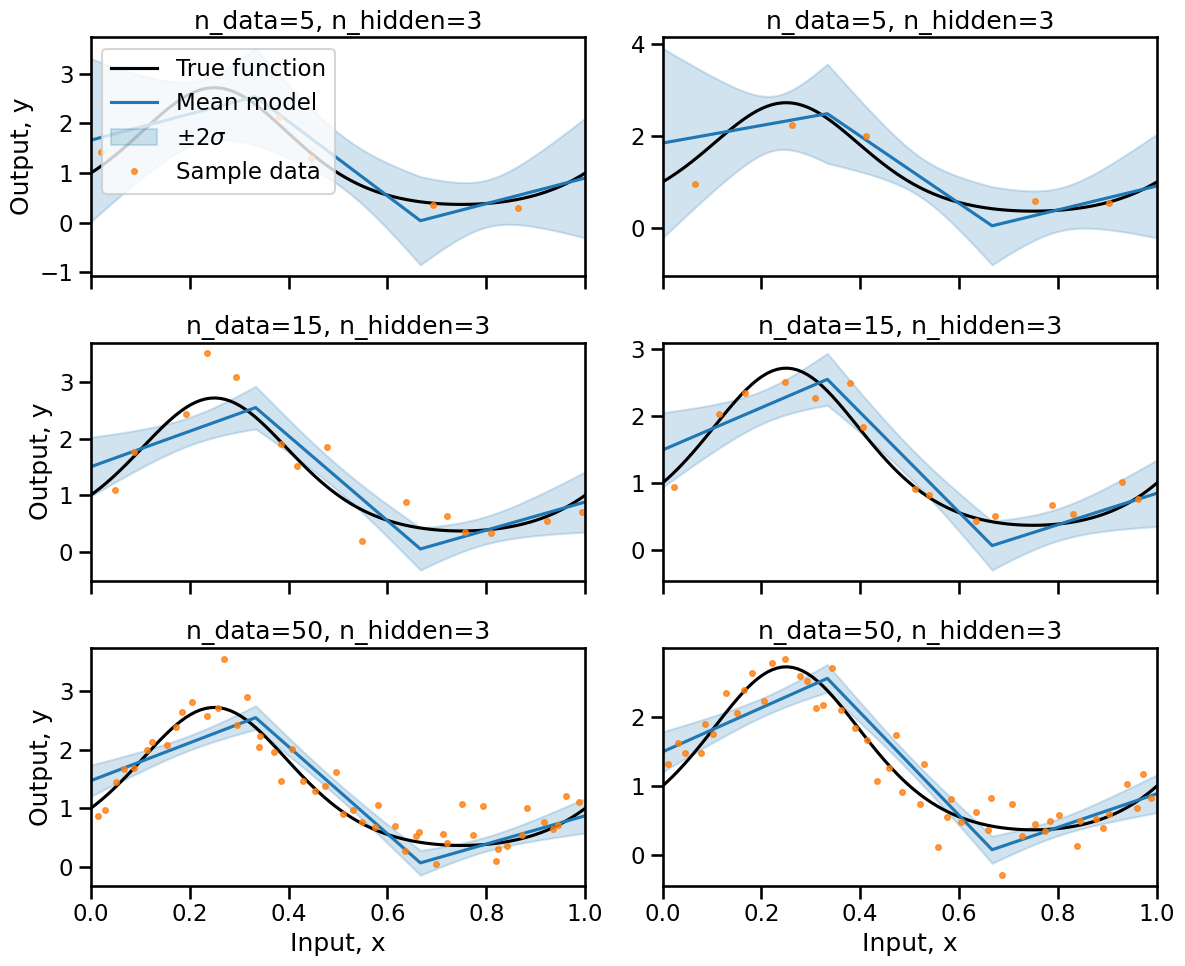

In [16]:
function_sigma = 0.3
n_datasets = 200

n_datas = [5, 15, 50]
ns      = [3, 3]

fig, axes = plt.subplots(len(n_datas), len(ns), figsize=(12, 10), sharex=True, sharey=False)

for i, n_data in enumerate(n_datas):
    for j, n_hidden in enumerate(ns):
        ax = axes[i, j]

        mean_model, std_model = get_model_mean_variance(
            n_data=n_data,
            n_datasets=n_datasets,
            n_hidden=n_hidden,
            function_sigma=function_sigma,
            solver=fit_model_closed_form,
        )

        # one sample dataset for context
        X_data, y_data = generate_data(n_data, sigma_y=function_sigma)

        ax.plot(x_func, y_func, "k-", label="True function" if (i==0 and j==0) else None)
        ax.plot(x_model, mean_model, color="C0", label="Mean model" if (i==0 and j==0) else None)
        ax.fill_between(x_model, mean_model - 2*std_model, mean_model + 2*std_model,
                        color="C0", alpha=0.2, label=r"$\pm 2\sigma$" if (i==0 and j==0) else None)
        ax.plot(X_data.squeeze(), y_data, "o", color="C1", ms=4, alpha=0.8,
                label="Sample data" if (i==0 and j==0) else None)

        ax.set_title(f"n_data={n_data}, n_hidden={n_hidden}")
        ax.set_xlim(0, 1)

for ax in axes[-1, :]:
    ax.set_xlabel("Input, x")
for ax in axes[:, 0]:
    ax.set_ylabel("Output, y")

axes[0,0].legend(loc="upper left", frameon=True)
plt.tight_layout()
plt.show()

The figure above shows how the bias-variance varies for a `n_hidden=3` varies as the number of training points increases from 5 to 50. The true function is shown as a black curve, with the dark blue line representing the mean prediction over resampled training set sizes. Where there's little data, the model shows high variance; this variance reduces as the number of data points increases. The bias doesn't change so much as the number of data points increases, as it's determined by the `n_hidden` ficed model capacity.

### Question 1.e

Complete the code below to vary the *model capacity*, i.e. the number of hidden units,  between 0 and 12 and compute the bias and variance for each model size. Produce a plot similar to the bias-variance tradeoff shown in the lecture. What is the optimal model capacity?

- **Variance** should be computed as the average of the model variance (average squared deviation of fitted models around mean fitted model)
- **Bias** is the average squared deviation of the mean model from the true function.

<div align="right">[10 points]</div>

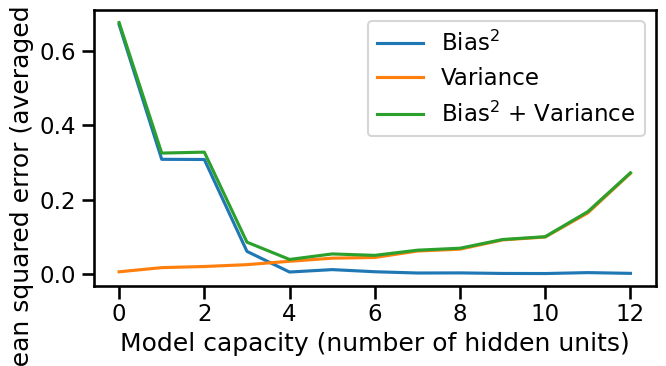

In [18]:
hidden_variables = range(13)
bias = np.zeros((len(hidden_variables), 1)) ;
variance = np.zeros((len(hidden_variables), 1)) ;

n_datasets = 100
n_data = 15
function_sigma = 0.3

# Set random seed so that get same result every time
np.random.seed(1)

for i, n_hidden in enumerate(hidden_variables):
    # Get mean and variance of fitted model
    mean_model, std_model = get_model_mean_variance(n_data, n_datasets, n_hidden, function_sigma)
    bias[i, 0] = np.mean((mean_model - y_func) ** 2)

    variance[i, 0] = np.mean(std_model ** 2)

hidden_variables = np.array(list(hidden_variables))

plt.figure(figsize=(7, 4))
plt.plot(hidden_variables, bias[:, 0], label="Bias$^2$")
plt.plot(hidden_variables, variance[:, 0], label="Variance")
plt.plot(hidden_variables, bias[:, 0] + variance[:, 0], label="Bias$^2$ + Variance")
plt.xlabel("Model capacity (number of hidden units)")
plt.ylabel("Mean squared error (averaged over x)")
plt.legend()
plt.tight_layout()
plt.show()

### Question 1.f

Briefly discuss how relevant the trends seen here would be expected to be to 'real' neural networks containing many hidden layers, and where training is carried out by stochastic gradient descent rather than through a least squares closed form solution. What role would regularisation play in the behaviour you have observed?

<div align="right">[5 points]</div>


For neural networks trained using stochastic gradient descent, the bias-variance tradeoff is less prevalent. Bias is reduced by increasing model capacity as larger networks are more capable of representing complicated functions, but this can cause variance to spike when the model overfits. Using model architecture choices such as residual connections, choice of activation function and limited width/depth can influence the model complexity. Large neural networks generalise well as a result of the implicit regularisation from stochastic gradient descent and overparameterisation.

Regularisation can control variance through data augmentation, early stopping, dropout layers, which can change the bias-variance tradeoff by penalising overfitting. The more regularisation there is, the less variance however this increases the bias, and vice-versa.

## Extension questions for Part I

### Extension Question 1

Add regularisation with an L2 ridge penalty of strength $\lambda$ to the loss function optimised by `fit_model_closed_form()`. Repeat the bias-variance tradeoff plot with several choices of $\lambda$ to see the effect, and comment on your results.

*Hint:* including the ridge penalty requires a simple modification of the solver, with the solution remaining analytic. Check that you get closely matching solutions to the original code when $\lambda=0$.

<div align="right">[10 points code + plot, 10 points for written comments]</div>

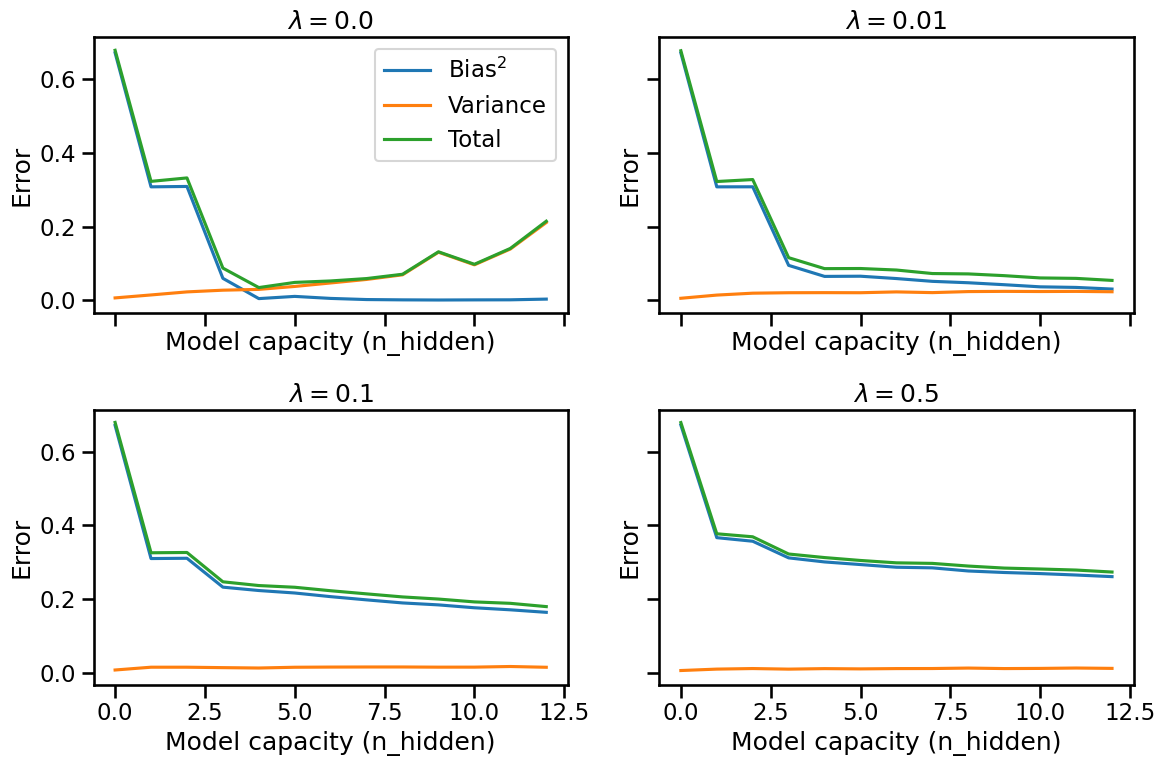

In [41]:
hidden_variables = list(range(13))
n_data = 15
n_datasets = 200
function_sigma = 0.3

x_model = np.linspace(0, 1, 100)
y_true = true_function(x_model)

lambdas = [0.0, 1e-2, 1e-1, 0.5]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.ravel()

for ax, lambd in zip(axes, lambdas):
    solver_ridge = lambda X, y, n_hidden: fit_model_with_ridge(X, y, n_hidden=n_hidden, lambd=lambd)

    bias2 = np.zeros(len(hidden_variables))
    var = np.zeros(len(hidden_variables))

    for i, n_hidden in enumerate(hidden_variables):
        mean, std = get_model_mean_variance(
            n_data=n_data,
            n_datasets=n_datasets,
            n_hidden=n_hidden,
            function_sigma=function_sigma,
            solver=solver_ridge
        )
        bias2[i] = np.mean((mean - y_true) ** 2)
        var[i] = np.mean(std ** 2)

    total = bias2 + var
    ax.plot(hidden_variables, bias2, label="Bias$^2$")
    ax.plot(hidden_variables, var, label="Variance")
    ax.plot(hidden_variables, total, label="Total")
    ax.set_title(fr"$\lambda={lambd}$")
    ax.set_xlabel("Model capacity (n_hidden)")
    ax.set_ylabel("Error")

axes[0].legend(loc="best", frameon=True)
plt.tight_layout()
plt.show()

For $\lambda = 0$, the total error follows the general case. The bias decreases as the model capacity increases until the model capacity introduces variance, causing an increase in error again. For $\lambda = 0.01$, the variance reduces, showing optimal capacity in larger models. In the case of $\lambda = 0.1$, the variance is almost negligible throughout the plot. The total error is a product of bias, which reduces as model capacity increases. The classical U-shape is not present, showing better performance in larger models. Similar holds true for when $\lambda = 0.5$, where the model is dominated by bias at high capacity. However, the total error decays slower as the regularisation prevents the model from fitting the true function closely.

### Extension Question 2 [Not for credit]

Adapt the PyTorch example code from the lecture to fit this model using stochastic gradient descent rather than using the closed form least squares solution. Produce a new bias-variance trade off plot and discuss any differences observed.

In [ ]:
# YOUR CODE HERE
#

YOUR ANSWER HERE

# Part 2. Ensembles of Models

In this section we will investigate how fitting several models and averaging over the results can help to reduce the generalisation gap between training and test data. One way to do this is to use different random initialisations for the weights. Since we are using a toy model which doesn't require stochastic gradient descent to optimise it we won't pursue that option here.

Instead, we'll generate several datasets by *resampling with replacement* from the training set (i.e. repeating some observations more than once) and then fitting models to each of them. This is referred to as *bootstrap aggregating* or *bagging* for short. 

To ensure a fair comparison we regenerate training data with a fixed random seed and fit a new model.

### Question 2.a

Add code to the cell below to fit the closed form solution, predict on inputs `x_model` and plot the resulting model. Note we are using a high model capacity of 14 hidden regions, which leads to overfitting with a single model.

Compute the mean squared error (MSE) between the fitted model and the true curve on the interval `x_model` and assign it to the variable `mean_sq_error`.

<div align="right">[5 points]</div>

mean_sq_error = 0.38877583398515086


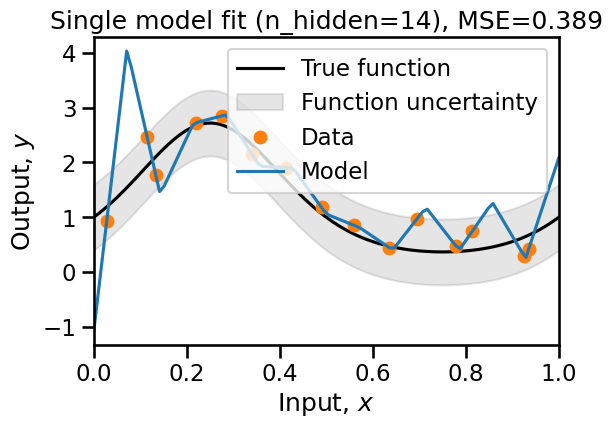

In [24]:
np.random.seed(1)
function_sigma = 0.3
n_data = 15
n_hidden = 14
X_data, y_data = generate_data(n_data, function_sigma)
x_model = np.linspace(0, 1, 100)

beta_pred, omega_pred = fit_model_closed_form(X_data, y_data, n_hidden=n_hidden)

y_model = network(x_model, beta_pred, omega_pred)
y_true = true_function(x_model)

mean_sq_error = np.mean((y_model - y_true) ** 2)
print("mean_sq_error =", mean_sq_error)


x_func = np.linspace(0, 1, 100)
y_func = true_function(x_func)

fig, ax = plt.subplots(figsize=(6, 4))
plot_function(
    x_func=x_func,
    y_func=y_func,
    X_data=X_data,
    y_data=y_data,
    x_model=x_model,
    y_model=y_model,
    function_sigma=function_sigma,
    ax=ax,
    data_fmt='o'
)
ax.set_title(f"Single model fit (n_hidden={n_hidden}), MSE={mean_sq_error:.3f}")
ax.legend()
plt.show()

In [25]:
assert abs(mean_sq_error - 0.3887758339) < 1e-4

### Question 2.b

Add code below to sample *with replacement* (i.e. duplicating some of the observations) from the data 10 times to fit 10 new models. Evaluate them on the same range of inputs and plot them on a single set of axes.

*Hint:* use [np.random.choice](https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html) to do the resampling, taking care to pass `replace=True`.

<div align="right">[10 points]</div>

Mean square error = 0.114
Mean square error = 0.234
Mean square error = 0.382
Mean square error = 0.110
Mean square error = 0.118
Mean square error = 0.201
Mean square error = 0.397
Mean square error = 0.417
Mean square error = 0.144
Mean square error = 0.215


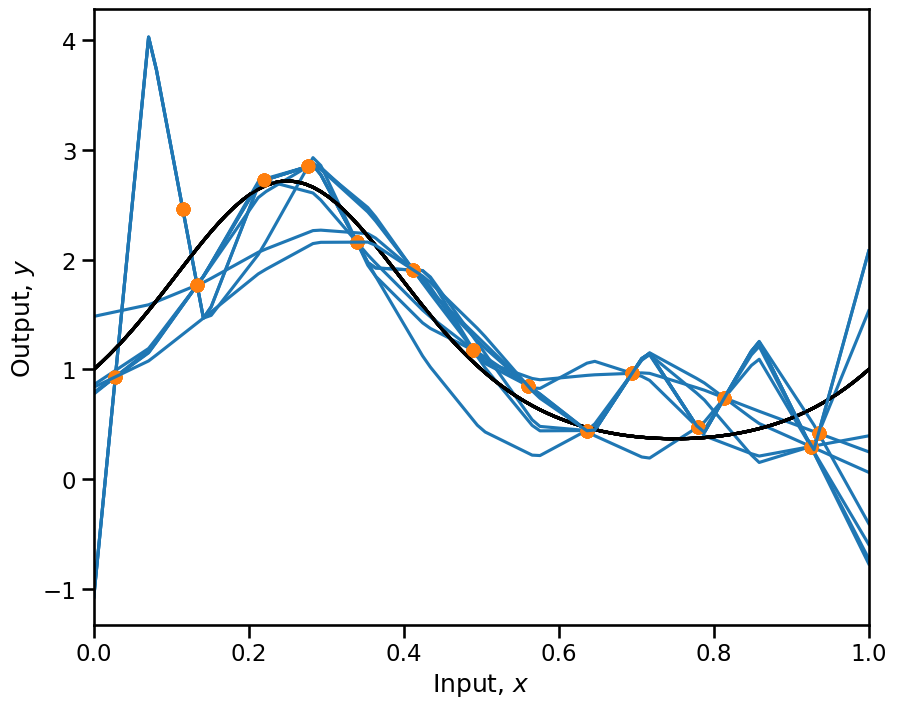

In [30]:
n_model = 10
n_sample = n_data
all_y_model = np.zeros((n_model, len(y_model)))

fig, ax = plt.subplots()

# For each model
for c_model in range(n_model):
    i = np.random.choice(n_data, size=n_sample, replace=True)
    X_boot = X_data[i, :]
    y_boot = y_data[i]
    beta, omega = fit_model_closed_form(X_boot, y_boot, n_hidden=n_hidden)
    # Run the model
    y_model_resampled = network(x_model, beta, omega)
    
    # Compute the mean squared error between the fitted model (blue) and the true curve (black)
    mean_sq_error = np.mean((y_model_resampled-y_func) * (y_model_resampled-y_func))
    print(f"Mean square error = {mean_sq_error:3.3f}")

    # Store the results
    all_y_model[c_model,:] = y_model_resampled

    # Draw the function and the model
    plot_function(x_func, y_func, X_data, y_data, x_model, y_model_resampled, ax=ax)

### Question 2.c

Compute the mean and median predictions from your ensemble of models and visualise them. Discuss how the performance of the mean and median models compares with that of the individual models.

<div align="right">[5 points plot + 5 points discussion]</div>

Ensemble mean MSE   = 0.093
Ensemble median MSE = 0.114


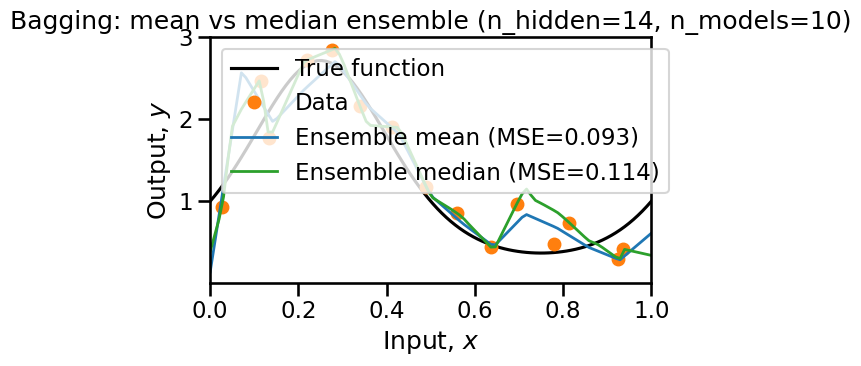

In [28]:
y_means = np.mean(all_y_model, axis=0)
y_meds = np.median(all_y_model, axis=0)

mse_mean = np.mean((y_means - y_true) ** 2)
mse_median = np.mean((y_meds - y_true) ** 2)
print(f"Ensemble mean MSE   = {mse_mean:.3f}")
print(f"Ensemble median MSE = {mse_median:.3f}")

fig, ax = plt.subplots(figsize=(6, 4))
plot_function(
    x_func=x_func,
    y_func=y_func,
    X_data=X_data,
    y_data=y_data,
    ax=ax,
    data_fmt='o'
)

ax.plot(x_model, y_means, color="C0", lw=2, label=f"Ensemble mean (MSE={mse_mean:.3f})")
ax.plot(x_model, y_meds, color="C2", lw=2, label=f"Ensemble median (MSE={mse_median:.3f})")

ax.set_title(f"Bagging: mean vs median ensemble (n_hidden={n_hidden}, n_models={n_model})")
ax.set_xlim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

In the individual model cases, the MSE can range from 0.11 to 0.42, with some curves show high variance. In the mean ensemble case, the MSE is 0.093, lower than all of the MSEs of the individual models. This shows that averaging smooths the idiosyncratic wiggles in the curve, reducing the variance. In the median ensemble case, it still outperforms most of the individual model cases with an MSE of 0.114, however it does not perform as strongly as the mean ensemble case, showing oscillatory behaviour.

## Part 3. Comparison of Neural Network and Gaussian Process Regression

In this part of the workshop we will refit the water molecule data from Workshop 4 with a neural network to see if we can reduce the model form error.

Paste code into the cell below to reproduce the descriptor computation, training data, optimised hyperparameters and GP fit from Workshop 4, which should give an RMSE of around 17 meV/atom (*Note: there is no credit for this since it has already been assessed; if you have an extension for Workshop 4 and have not yet completed it please let me know*).

In [34]:
from ase import Atoms
from ase.io import read
from sklearn.model_selection import train_test_split

import numpy as np
from ase import Atoms

from jax import jit, grad, vmap
import jax.numpy as jnp
import jax.random as jr
import tinygp
from jax import config
config.update("jax_enable_x64", True)     # use double rather than single precision floats
config.update('jax_platform_name', 'cpu') # use CPU rather than GPU

from gputils import gp_print, gp_plot, gp_fit, gp_fit_restarts

key = jr.PRNGKey(123)

from ase.io import read
from ase.build import molecule
import nglview

from IPython.display import display

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context('talk')

def descriptors(config: Atoms) -> np.array:
    O_i = 0
    H1_i = 1
    H2_i = 2

    r_OH1 = config.get_distance(O_i, H1_i)
    r_OH2 = config.get_distance(O_i, H2_i)

    pos = config.positions
    vec_OH1 = pos[H1_i] - pos[O_i]
    vec_OH2 = pos[H2_i] - pos[O_i]

    
    # r+ = r_OH1 + r_OH2
    r_plus = r_OH1 + r_OH2

    # r- = (r_OH1 - r_OH2)^2
    r_minus = (r_OH1 - r_OH2)**2

    # a = r_OH1 . r_OH2 (dot product)
    # The formula is the dot product of the two bond vectors
    a = np.dot(vec_OH1, vec_OH2)

    return np.array([r_plus, r_minus, a])

water_configs = read("water_configs.xyz", ":")

c = molecule('H2O')
c.positions = np.array([[ 0.16243454, -0.06117564,  0.06644482],
                        [-0.10729686,  0.84977976, -0.70720087],
                        [ 0.17448118, -0.83935969, -0.44514309]])

d1 = descriptors(c)
assert type(d1) == np.ndarray
assert len(d1) == 3
assert abs(d1 - [ 2.15656638,  0.08634174, -0.31635254]).max() < 1e-8

# also check a shifted cell
c.center()
d2 = descriptors(c)
assert abs(d1 - d2).max() < 1e-8

# and a rotated one
c.rotate(45, 'z')
d3 = descriptors(c)
assert abs(d1 - d3).max() < 1e-8

x = [] # input features
y = [] # target values

# Calculate descriptor vectors for each molecule and collect target energies
for config in water_configs:
    x.append(descriptors(config))
    y.append(config.get_potential_energy()) # QM energy of a water molecule  

from sklearn.model_selection import train_test_split

# test_size sets the fraction of the test set
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.9, random_state=42) 

X_train = np.array(X_train)
y_train = np.array(y_train)

X_test = np.array(X_test)
y_test = np.array(y_test)

print('Range of X inputs: {}'.format(X_train.max(axis=0) - X_train.min(axis=0)))
print("Range of Y values: {:.2f}".format(y_train.max()-y_train.min()))

def build_gp(params, X_):
    inv_lengthscale = 1.0 / params["lengthscale"]
    base_kernel = tinygp.kernels.ExpSquared()
    kernel = params["variance"] * tinygp.transforms.Linear(inv_lengthscale, base_kernel)
    return tinygp.GaussianProcess(kernel, X_, diag=params["noise_variance"])

params = {'variance': 1.0, 
          'lengthscale': jnp.array([2.0, 2.0, 4.0]), 
          'noise_variance': 1.0}

negative_mll, learned_params = gp_fit_restarts(
    key, 
    build_gp, 
    X_train, 
    y_train, 
    params
)
key = jax.random.PRNGKey(42)

gp = build_gp(learned_params, X_train)
full_X = jnp.vstack([X_train, X_test])

cond_gp = gp.condition(y_train, full_X, diag=learned_params["noise_variance"]).gp

mean = cond_gp.mean
variance = cond_gp.variance

N_train = len(X_train)
y_hat_tests = mean[N_train:]

rmse = jnp.sqrt(jnp.mean((y_hat_tests - y_test) ** 2))

ev_rmse = rmse * 1000 / 3
rmse = ev_rmse
print(f"Test RMSE: {rmse:.4f} meV/atom")

Range of X inputs: [1.98947368 1.1025     4.61207359]
Range of Y values: 17.79
Fit 1/5: -288.5489 (new global minimum) {'lengthscale': Array([0.89942702, 2.44180172, 1.54981848], dtype=float64), 'noise_variance': Array(0.00030914, dtype=float64), 'variance': Array(66958.85085959, dtype=float64)}
Fit 2/5: -288.5489  {'lengthscale': Array([0.89942707, 2.44197627, 1.54987205], dtype=float64), 'noise_variance': Array(0.00030913, dtype=float64), 'variance': Array(66972.350902, dtype=float64)}
Fit 3/5: -288.5489 (new global minimum) {'lengthscale': Array([0.8994608 , 2.44228149, 1.54990166], dtype=float64), 'noise_variance': Array(0.00030914, dtype=float64), 'variance': Array(67009.94772572, dtype=float64)}
Fit 4/5: -288.5489  {'lengthscale': Array([0.89942761, 2.44180027, 1.54981753], dtype=float64), 'noise_variance': Array(0.00030914, dtype=float64), 'variance': Array(66958.45970362, dtype=float64)}
Fit 5/5: -288.5489  {'lengthscale': Array([0.89942623, 2.4417525 , 1.54982583], dtype=float

The next step is to train a neural network on the same data. The code below converts from numpy arrays to PyTorch tensors and sets up a dataloader for the training data.

In [35]:
batch_size = 20 # feel free to change this!

# convert data points and store in data loader class
X_train = torch.tensor(X_train.astype('float32'))
y_train = torch.tensor(y_train.astype('float32')[:, None])
X_test = torch.tensor(X_test.astype('float32'))
y_test = torch.tensor(y_test.astype('float32')[:, None])

# load the data into a class that creates the batches
data_loader = DataLoader(TensorDataset(X_train,y_train), batch_size=batch_size, shuffle=True, 
                         worker_init_fn=np.random.seed(1))

### Question 3.a

Define a `torch.nn.Sequential()` MLP model with an input layer going from `X_train.shape[1]` (i.e. 3 with the invariant descriptors) to `D_k`, two hidden layers of size `D_k` with ReLU activation functions and an output layer than maps down to a single scalar.

Name your model `model` and ensure all the automatic tests pass before moving on.

<div align="right">[5 points]</div>

In [36]:
D_i = 3    # Input dimensions
D_k = 64  # Hidden dimensions - experiment with this!
D_o = 1    # Output dimensions

random_state = 2 # for reproducibility - but do try changing
torch.manual_seed(random_state)

model = nn.Sequential(
    nn.Linear(X_train.shape[1], D_k),
    nn.ReLU(),
    nn.Linear(D_k, D_k),
    nn.ReLU(),
    nn.Linear(D_k, D_k),
    nn.ReLU(),
    nn.Linear(D_k, 1)
)

torchsummary.summary(model, X_train.shape)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1              [-1, 288, 64]             256
              ReLU-2              [-1, 288, 64]               0
            Linear-3              [-1, 288, 64]           4,160
              ReLU-4              [-1, 288, 64]               0
            Linear-5              [-1, 288, 64]           4,160
              ReLU-6              [-1, 288, 64]               0
            Linear-7               [-1, 288, 1]              65
Total params: 8,641
Trainable params: 8,641
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.85
Params size (MB): 0.03
Estimated Total Size (MB): 0.88
----------------------------------------------------------------


In [37]:
assert len(model) == 7

assert isinstance(model[0], nn.Linear)
assert model[0].in_features == D_i
assert model[0].out_features == D_k

assert isinstance(model[1], torch.nn.modules.activation.ReLU)

assert isinstance(model[2], nn.Linear)
assert model[2].in_features == D_k
assert model[2].out_features == D_k

assert isinstance(model[3], torch.nn.modules.activation.ReLU)

assert isinstance(model[4], nn.Linear)
assert model[4].in_features == D_k
assert model[4].out_features == D_k

assert isinstance(model[5], torch.nn.modules.activation.ReLU)

assert isinstance(model[6], nn.Linear)
assert model[6].in_features == D_k
assert model[6].out_features == D_o

Use the training code below as a starting point. You should explore the effect of changing the learning rate and the associated scheduler which decreases it over time, the number of epochs and the random seed on the results.

Once you've explored those parameters you can also change the network architecture (although you'll need to redefine `model` in the cell below so that the automatic tests above still pass).

**Note**: The training code provided does not implement *early stopping* as discussed in Lecture 5. As you experiment with the parameters, observe how the training and test errors evolve - you may see the test error start to increase even as the training error continues to decrease, which is a sign of overfitting. In practice, you would checkpoint the model with the lowest test error and use that for predictions.

In [38]:
# parameters to explore
learning_rate = 1e-3
n_epoch = 2000
momentum = 0.9

loss_function = torch.nn.MSELoss()

# construct SGD optimizer and initialize learning rate and momentum
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum)

# object that decreases learning rate by half every 100 epochs
scheduler = StepLR(optimizer, step_size=100, gamma=0.5)

# store the loss and the RMSE at each epoch
losses_train = np.zeros(n_epoch)
errors_train = np.zeros(n_epoch)
losses_test = np.zeros(n_epoch)
errors_test = np.zeros(n_epoch)

for epoch in range(n_epoch):
    # loop over batches
    for i, batch in enumerate(data_loader):
        # retrieve inputs and labels for this batch
        x_batch, y_batch = batch
        # zero the parameter gradients
        optimizer.zero_grad()
        # forward pass -- calculate model output
        pred = model(x_batch)
        # compute the loss
        loss = loss_function(pred, y_batch)
        # backward pass
        loss.backward()
        # SGD update
        optimizer.step()

    # Run whole dataset to get error statistics -- normally wouldn't do this
    pred_train = model(X_train)
    pred_test = model(X_test)
    errors_train[epoch] = torch.sqrt(torch.mean(pred_train - y_train)**2) * 1000/3
    errors_test[epoch]= torch.sqrt(torch.mean(pred_test - y_test)**2) * 1000/3
    losses_train[epoch] = loss_function(pred_train, y_train).item()
    losses_test[epoch]= loss_function(pred_test, y_test).item()
    if epoch % 100 == 0:
        print(f'Epoch {epoch:5d}, train loss {losses_train[epoch]:8.3f}, train RMSE {errors_train[epoch]:6.2f},  test loss {losses_test[epoch]:8.3f}, test RMSE {errors_test[epoch]:6.2f}')

    # tell scheduler to consider updating learning rate
    scheduler.step()

Epoch     0, train loss   10.322, train RMSE 462.09,  test loss   12.210, test RMSE 545.77
Epoch   100, train loss    0.064, train RMSE   8.30,  test loss    0.167, test RMSE  13.91
Epoch   200, train loss    0.031, train RMSE  11.96,  test loss    0.097, test RMSE  17.65
Epoch   300, train loss    0.020, train RMSE   1.15,  test loss    0.074, test RMSE   0.62
Epoch   400, train loss    0.017, train RMSE   2.75,  test loss    0.068, test RMSE   3.99
Epoch   500, train loss    0.016, train RMSE   1.39,  test loss    0.066, test RMSE   2.02
Epoch   600, train loss    0.016, train RMSE   1.07,  test loss    0.065, test RMSE   0.39
Epoch   700, train loss    0.016, train RMSE   0.32,  test loss    0.065, test RMSE   1.34
Epoch   800, train loss    0.016, train RMSE   0.78,  test loss    0.065, test RMSE   1.85
Epoch   900, train loss    0.016, train RMSE   0.06,  test loss    0.064, test RMSE   1.18
Epoch  1000, train loss    0.015, train RMSE   0.72,  test loss    0.064, test RMSE   1.89

### Question 3.b

Produce a plot to show the training and test error as a function of the number of epochs. Add horizontal lines to compare with the results of the GP fit. Can you improve upon its accuracy?

Take care to ensure your plot is reproducible when the notebook is restarted (e.g. by fixing all the random seeds in the training code above).

<div align="right">[5 points]</div>

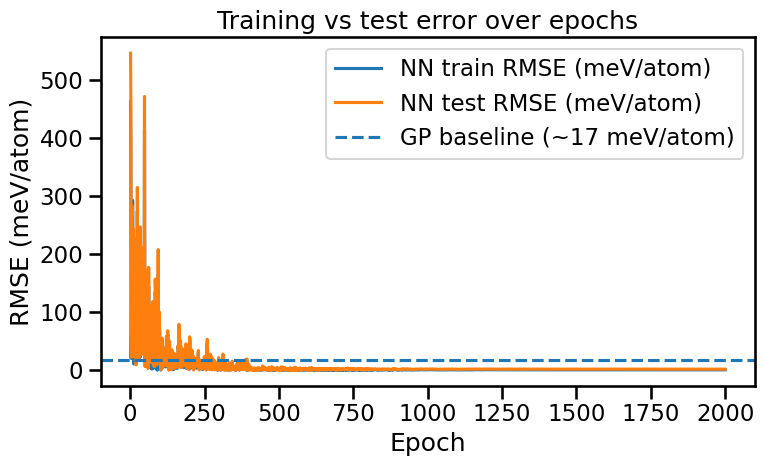

In [39]:
epochs = np.arange(1, n_epoch + 1)

gp_rmse_meV = 17.0  # from Workshop 4 target ~17 meV/atom

plt.figure(figsize=(8, 5))
plt.plot(epochs, errors_train, label="NN train RMSE (meV/atom)")
plt.plot(epochs, errors_test, label="NN test RMSE (meV/atom)")
plt.axhline(gp_rmse_meV, linestyle="--", label=f"GP baseline (~{gp_rmse_meV:.0f} meV/atom)")

plt.xlabel("Epoch")
plt.ylabel("RMSE (meV/atom)")
plt.title("Training vs test error over epochs")
plt.legend()
plt.tight_layout()
plt.show()

### Question 3.c

Compare your GP and NN fits to the water molecule dataset, addressing the following questions:

1. Which model was easier to get a good result with? 
2. Which model is more at risk of overfitting?
3. What is the analogue of the bias-variance trade-off in the GP case?
4. How do the costs of (a) training and (b) predicting with the GP and NN models compare? How does this change as the quantity of training data $N_d$ or the number of hidden units $N_h$ is increased?

You can use the cell below to compare timings of the GP and NN models for predictions to help in your answer.

<div align="right">[10 points]</div>

In [40]:
from gputils import repredict # only does the linear algebra necessary for prediction at new points

X_test_jax = jnp.array(X_test)

@jax.jit
def gpr_predict(X_test_jax):
    return repredict(gp, cond_gp, X_test_jax)

print('GP prediction time:')
%timeit gpr_predict(X_test_jax)
print('NN prediction time:')
%timeit model(X_test)

GP prediction time:
8.42 ms ± 397 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
NN prediction time:
913 μs ± 29.6 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


1. The GP was easiest to get a good result with as training becomes a task of optimising a small number of hyperparameters by marginal likelihood maximisation. The solution is not prone to problems NNs face such as vanishing gradients, weight initialisation sensitivity, as well as architectural design choice such asas optimiser, architecture and number of epochs.
2. The NN is at most risk of overfitting; it does not encode smoothness or physical assumptions unless regularised as such, and they are prone to fitting noise. In comparison, a GP can define lengthscale and variance, implicitly serving as regularisers.
3. The analogue of the bias-variance trade-off in the GP is controlled by the kernel hyperparameters. A large lengthscale smooths functions, reducing variance whilst increasing bias. On the other hand, a smaller lengthscale offers more flexibility for function wiggles, reducing bias with a higher variance. The noise variance parameter offers a smoother posterior, in turn increasing bias. A smaller noise variance parameter has a tighter fit with more variance. This smoothness encoded in the kernel determines the model capacity, rather than hidden units as in the NN case.
4. The training cost of the GP has time complexity $\mathcal{O}(N^3_d)$ where $N_d$ is the number of training points. This is because the kernel matrix is inverted. For larger datasets, a GP solution can become intractable. For a NN, training scales by $\mathcal{O}(N_d\times N_h\times e)$ where $N_h, e$ are the number of hidden layers and number of epochs respectively. From the timed results, the GP takes 8.42 milliseconds for a prediction whereas the NN takes 913 $\mu$s, a considerable speed up.

### Extension Questions for Part 3 [Not for Credit]

**Extension Question 1**

Modify the network architecture. How much can you improve upon the 17 meV/at RMSE of the GP model?

In [ ]:
# YOUR CODE HERE
raise NotImplementedError()

**Extension Question 2**

Experiment with alternative descriptors which use the bond lengths and angles directly without symmetrisation, or with all 9 coordinates of the 3 atoms that make up the molecule. Can you build a network which removes the need for invariant descriptors?

In [ ]:
# YOUR CODE HERE
raise NotImplementedError()

**Extension Question 3**

Repeat the geometry optimisation exercise from Workshop 3 with the neural network model. Does it perform as well as the GP? If not why not?

*Hint:* the 32-bit float precision used in the PyTorch model may cause problems when optimising the molecular geometry, as may any symmetry violations if you aren't using the invariant descriptors.

In [ ]:
# YOUR CODE HERE
raise NotImplementedError()